In [1]:
import os
print(os.listdir())
!rm -rf dataset dataset.zip checkpoints
print(os.listdir())

['.config', 'sample_data']
['.config', 'sample_data']


In [2]:
%pip install -q gdown
import gdown

gdown.download("https://drive.google.com/uc?id=1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ", "dataset.zip", quiet=False)
!unzip -q dataset.zip -d dataset

Downloading...
From (original): https://drive.google.com/uc?id=1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ
From (redirected): https://drive.google.com/uc?id=1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ&confirm=t&uuid=4154a81d-7ed8-41e6-9724-c627240b9739
To: /content/dataset.zip
100%|██████████| 1.13G/1.13G [00:15<00:00, 73.0MB/s]


In [3]:
ls dataset/dataset

train/  val/


In [4]:
import os
import numpy as np

data_root = "dataset/dataset"

for split in ["train", "val"]:
    path = os.path.join(data_root, split)
    classes = sorted([d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))])
    print(f"\n{split.upper()} — Classes: {classes}")
    for cls in classes:
        cls_path = os.path.join(path, cls)
        files = [f for f in os.listdir(cls_path) if f.endswith('.npy')]
        sample = np.load(os.path.join(cls_path, files[0]))
        print(f"  {cls}: {len(files)} images, shape={sample.shape}, dtype={sample.dtype}, range=[{sample.min():.3f}, {sample.max():.3f}]")



TRAIN — Classes: ['no', 'sphere', 'vort']
  no: 10000 images, shape=(1, 150, 150), dtype=float64, range=[0.000, 1.000]
  sphere: 10000 images, shape=(1, 150, 150), dtype=float64, range=[0.000, 1.000]
  vort: 10000 images, shape=(1, 150, 150), dtype=float64, range=[0.000, 1.000]

VAL — Classes: ['no', 'sphere', 'vort']
  no: 2500 images, shape=(1, 150, 150), dtype=float64, range=[0.000, 1.000]
  sphere: 2500 images, shape=(1, 150, 150), dtype=float64, range=[0.000, 1.000]
  vort: 2500 images, shape=(1, 150, 150), dtype=float64, range=[0.000, 1.000]


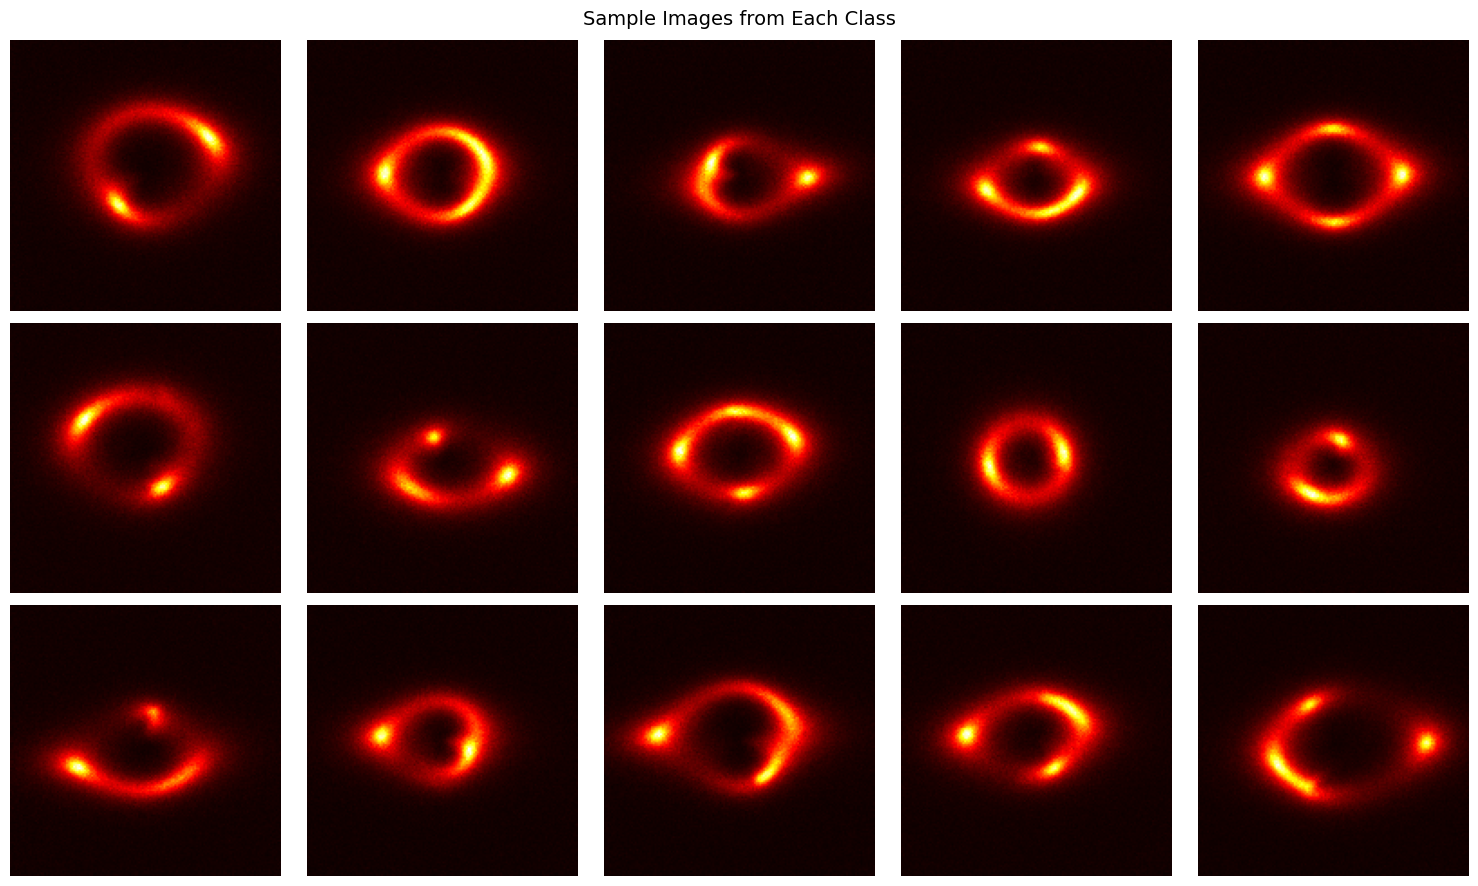

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
class_names = ["no", "sphere", "vort"]
class_labels = ["No Substructure", "CDM Subhalos", "Axion Vortex"]

for i, (cls, label) in enumerate(zip(class_names, class_labels)):
    cls_path = os.path.join(data_root, "train", cls)
    files = sorted([f for f in os.listdir(cls_path) if f.endswith('.npy')])
    for j in range(5):
        img = np.load(os.path.join(cls_path, files[j]))
        axes[i, j].imshow(img[0], cmap='hot')
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_ylabel(label, fontsize=12, rotation=0, labelpad=100)

plt.suptitle("Sample Images from Each Class", fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

# --- Custom Dataset ---
class LensingDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform
        class_names = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {c: i for i, c in enumerate(class_names)}

        for cls in class_names:
            cls_path = os.path.join(root_dir, cls)
            for f in os.listdir(cls_path):
                if f.endswith('.npy'):
                    self.samples.append((os.path.join(cls_path, f), self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = np.load(path).astype(np.float32)  # (1, 150, 150)
        img = torch.from_numpy(img)
        if self.transform:
            img = self.transform(img)
        return img, label

# --- Augmentation ---
train_transform = transforms.Compose([
    transforms.RandomRotation(180),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
])

# --- DataLoaders ---
train_dataset = LensingDataset(os.path.join(data_root, "train"), transform=train_transform)
val_dataset = LensingDataset(os.path.join(data_root, "val"), transform=None)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")
print(f"Classes: {train_dataset.class_to_idx}")

# --- Model ---
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)  # 1-channel input
model.fc = nn.Linear(model.fc.in_features, 3)  # 3 classes

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Device: {device}")
print(f"Model params: {sum(p.numel() for p in model.parameters()):,}")


Train: 30000 | Val: 7500
Classes: {'no': 0, 'sphere': 1, 'vort': 2}
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 173MB/s]


Device: cuda
Model params: 11,171,779


## 4. Training and Validation

This section trains the classifier with:
- Cross-entropy loss
- AdamW optimizer
- ReduceLROnPlateau scheduler
- Best-checkpoint saving by validation macro AUC

It also tracks loss, accuracy, and macro AUC each epoch.

Epoch 01/20 | train_loss=1.1106 | val_loss=1.0789 | val_acc=0.3908 | val_auc_macro_ovr=0.5810 | lr=1.00e-04
Epoch 02/20 | train_loss=0.9924 | val_loss=1.1946 | val_acc=0.4719 | val_auc_macro_ovr=0.7387 | lr=1.00e-04
Epoch 03/20 | train_loss=0.7908 | val_loss=0.7261 | val_acc=0.6863 | val_auc_macro_ovr=0.8762 | lr=1.00e-04
Epoch 04/20 | train_loss=0.6122 | val_loss=0.5314 | val_acc=0.7771 | val_auc_macro_ovr=0.9238 | lr=1.00e-04
Epoch 05/20 | train_loss=0.5068 | val_loss=0.4469 | val_acc=0.8173 | val_auc_macro_ovr=0.9467 | lr=1.00e-04
Epoch 06/20 | train_loss=0.4599 | val_loss=0.5033 | val_acc=0.8121 | val_auc_macro_ovr=0.9461 | lr=1.00e-04
Epoch 07/20 | train_loss=0.4115 | val_loss=0.4101 | val_acc=0.8496 | val_auc_macro_ovr=0.9623 | lr=1.00e-04
Epoch 08/20 | train_loss=0.3894 | val_loss=0.4352 | val_acc=0.8519 | val_auc_macro_ovr=0.9595 | lr=1.00e-04
Epoch 09/20 | train_loss=0.3641 | val_loss=0.3540 | val_acc=0.8651 | val_auc_macro_ovr=0.9670 | lr=1.00e-04
Epoch 10/20 | train_loss=0.3

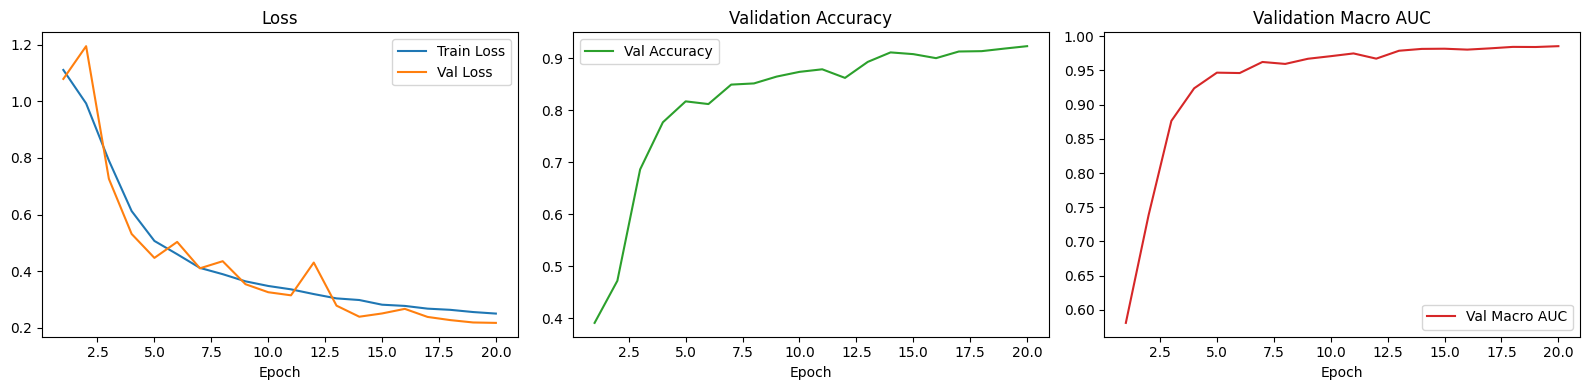

In [7]:
import random
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_auc_score, accuracy_score

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2, min_lr=1e-6
)

num_epochs = 20
best_auc = -1.0
history = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc_macro_ovr": [],
}

ckpt_dir = Path("checkpoints")
ckpt_dir.mkdir(exist_ok=True)
best_ckpt_path = ckpt_dir / "best_resnet18_lensing.pt"


def run_validation(model, loader, criterion, device):
    model.eval()
    val_loss = 0.0
    all_logits = []
    all_targets = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            loss = criterion(logits, y)

            val_loss += loss.item() * x.size(0)
            all_logits.append(logits.detach().cpu())
            all_targets.append(y.detach().cpu())

    val_loss /= len(loader.dataset)
    all_logits = torch.cat(all_logits).numpy()
    all_targets = torch.cat(all_targets).numpy()

    probs = torch.softmax(torch.tensor(all_logits), dim=1).numpy()
    preds = np.argmax(probs, axis=1)

    val_acc = accuracy_score(all_targets, preds)
    val_auc = roc_auc_score(all_targets, probs, multi_class="ovr", average="macro")

    return val_loss, val_acc, val_auc


for epoch in range(1, num_epochs + 1):
    model.train()
    running_loss = 0.0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    val_loss, val_acc, val_auc = run_validation(model, val_loader, criterion, device)

    scheduler.step(val_auc)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_auc_macro_ovr"].append(val_auc)

    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_auc_macro_ovr": val_auc,
                "class_to_idx": train_dataset.class_to_idx,
            },
            best_ckpt_path,
        )

    current_lr = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch {epoch:02d}/{num_epochs} | "
        f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f} | val_auc_macro_ovr={val_auc:.4f} | lr={current_lr:.2e}"
    )

print(f"\nBest val macro AUC: {best_auc:.4f}")
print(f"Saved best checkpoint to: {best_ckpt_path}")

# Plot training curves
epochs = range(1, num_epochs + 1)
fig, axs = plt.subplots(1, 3, figsize=(16, 4))

axs[0].plot(epochs, history["train_loss"], label="Train Loss")
axs[0].plot(epochs, history["val_loss"], label="Val Loss")
axs[0].set_title("Loss")
axs[0].set_xlabel("Epoch")
axs[0].legend()

axs[1].plot(epochs, history["val_acc"], label="Val Accuracy", color="tab:green")
axs[1].set_title("Validation Accuracy")
axs[1].set_xlabel("Epoch")
axs[1].legend()

axs[2].plot(epochs, history["val_auc_macro_ovr"], label="Val Macro AUC", color="tab:red")
axs[2].set_title("Validation Macro AUC")
axs[2].set_xlabel("Epoch")
axs[2].legend()

plt.tight_layout()
plt.show()

Classification report:
              precision    recall  f1-score   support

          no     0.9043    0.9784    0.9399      2500
      sphere     0.9551    0.8420    0.8950      2500
        vort     0.9170    0.9504    0.9334      2500

    accuracy                         0.9236      7500
   macro avg     0.9255    0.9236    0.9228      7500
weighted avg     0.9255    0.9236    0.9228      7500

Confusion matrix:
 [[2446   34   20]
 [ 200 2105  195]
 [  59   65 2376]]
Macro ROC-AUC (OvR): 0.9854


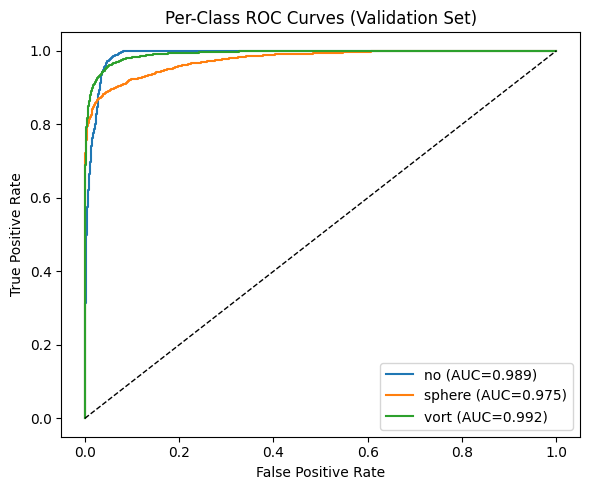

In [8]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Load best checkpoint and evaluate thoroughly
# PyTorch 2.6+: torch.load defaults to weights_only=True.
# This checkpoint is locally created in this notebook, so full load is safe.
ckpt = torch.load(best_ckpt_path, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

all_logits = []
all_targets = []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        logits = model(x)
        all_logits.append(logits.detach().cpu())
        all_targets.append(y)

all_logits = torch.cat(all_logits).numpy()
all_targets = torch.cat(all_targets).numpy()
all_probs = torch.softmax(torch.tensor(all_logits), dim=1).numpy()
all_preds = np.argmax(all_probs, axis=1)

idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}
class_names = [idx_to_class[i] for i in range(len(idx_to_class))]

print("Classification report:")
print(classification_report(all_targets, all_preds, target_names=class_names, digits=4))

cm = confusion_matrix(all_targets, all_preds)
print("Confusion matrix:\n", cm)

# Per-class ROC and AUC
n_classes = len(class_names)
y_true_bin = label_binarize(all_targets, classes=list(range(n_classes)))

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

macro_auc = roc_auc_score(all_targets, all_probs, multi_class="ovr", average="macro")
print(f"Macro ROC-AUC (OvR): {macro_auc:.4f}")

plt.figure(figsize=(6, 5))
for i, cname in enumerate(class_names):
    plt.plot(fpr[i], tpr[i], label=f"{cname} (AUC={roc_auc[i]:.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Per-Class ROC Curves (Validation Set)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [9]:
import json

results = {
    "best_val_macro_auc": float(best_auc),
    "final_val_macro_auc": float(macro_auc),
    "classes": class_names,
    "num_train": len(train_dataset),
    "num_val": len(val_dataset),
    "seed": SEED,
    "epochs": num_epochs,
    "batch_size": 64,
    "optimizer": "AdamW",
    "scheduler": "ReduceLROnPlateau",
}

with open("test1_results_summary.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved summary to test1_results_summary.json")
results

Saved summary to test1_results_summary.json


{'best_val_macro_auc': 0.9854035466666667,
 'final_val_macro_auc': 0.9854035466666667,
 'classes': ['no', 'sphere', 'vort'],
 'num_train': 30000,
 'num_val': 7500,
 'seed': 42,
 'epochs': 20,
 'batch_size': 64,
 'optimizer': 'AdamW',
 'scheduler': 'ReduceLROnPlateau'}

## Results Interpretation

The ResNet18 baseline trained on the DeepLense Test I dataset shows strong separability across classes, reaching a best validation macro ROC-AUC of **0.9854** and validation accuracy of **0.9236**. The training dynamics are stable: performance starts near chance in early epochs and then improves consistently after epoch 3, indicating successful feature learning rather than noisy fluctuation.

Class-wise behavior reveals a clear pattern. The **no-substructure** class has high recall (**0.9784**) and improved precision (**0.9043**), while **sphere** remains the hardest class with recall of **0.8420** and precision **0.9551**. The **vort** class performs strongly overall (precision **0.9170**, recall **0.9504**, F1 **0.9334**). The confusion matrix shows that the largest error source is **sphere being predicted as no** (200 samples), though this improved substantially compared to early training runs — suggesting that the lower learning rate (1e-4) and longer training (20 epochs) helped the model learn subtler CDM subhalo features.

Overall, the model achieves robust multi-class discrimination with a macro AUC close to 0.99, suitable as a strong baseline for downstream DeepLense tasks.

In [10]:
# --- Multi-seed quick runner (minimal) ---
# Assumes your existing dataset/model/training utilities are already in notebook scope.
# If not, run previous cells first.

import json
import copy
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from sklearn.metrics import roc_auc_score, accuracy_score
from torchvision import models

SEEDS = [42, 123]   # add more later if needed
NUM_EPOCHS = 20
BATCH_SIZE = 64
out_dir = Path("multiseed_results")
out_dir.mkdir(exist_ok=True)

def set_seed(seed):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def build_model(device):
    m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    m.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    m.fc = nn.Linear(m.fc.in_features, 3)
    return m.to(device)

def validate_model(model, loader, criterion, device):
    model.eval()
    val_loss = 0.0
    all_logits, all_targets = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            val_loss += loss.item() * x.size(0)
            all_logits.append(logits.detach().cpu())
            all_targets.append(y.detach().cpu())

    val_loss /= len(loader.dataset)
    logits_np = torch.cat(all_logits).numpy()
    y_true = torch.cat(all_targets).numpy()
    probs = torch.softmax(torch.tensor(logits_np), dim=1).numpy()
    y_pred = np.argmax(probs, axis=1)

    val_acc = accuracy_score(y_true, y_pred)
    val_auc = roc_auc_score(y_true, probs, multi_class="ovr", average="macro")
    return val_loss, val_acc, val_auc, y_true, probs

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()
results = []

for seed in SEEDS:
    print(f"\n=== Running seed {seed} ===")
    set_seed(seed)

    model = build_model(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=2, min_lr=1e-6
    )

    best_auc = -1.0
    best_state = None

    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        running_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        val_loss, val_acc, val_auc, _, _ = validate_model(model, val_loader, criterion, device)
        scheduler.step(val_auc)

        if val_auc > best_auc:
            best_auc = val_auc
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"seed={seed} epoch={epoch:02d} "
            f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
            f"val_acc={val_acc:.4f} val_auc={val_auc:.4f}"
        )

    # final eval on best state
    model.load_state_dict(best_state)
    _, final_acc, final_auc, y_true, probs = validate_model(model, val_loader, criterion, device)

    run = {
        "seed": seed,
        "best_val_macro_auc": float(best_auc),
        "final_val_macro_auc": float(final_auc),
        "final_val_acc": float(final_acc),
        "num_epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE
    }
    results.append(run)

    with open(out_dir / f"summary_seed_{seed}.json", "w") as f:
        json.dump(run, f, indent=2)

# aggregate
aucs = [r["final_val_macro_auc"] for r in results]
accs = [r["final_val_acc"] for r in results]
agg = {
    "seeds": SEEDS,
    "macro_auc_mean": float(np.mean(aucs)),
    "macro_auc_std": float(np.std(aucs)),
    "acc_mean": float(np.mean(accs)),
    "acc_std": float(np.std(accs)),
    "runs": results
}
with open(out_dir / "summary_multiseed.json", "w") as f:
    json.dump(agg, f, indent=2)

print("\n=== Multi-seed summary ===")
print(agg)


=== Running seed 42 ===
seed=42 epoch=01 train_loss=1.1085 val_loss=1.0746 val_acc=0.4031 val_auc=0.5961
seed=42 epoch=02 train_loss=0.9630 val_loss=0.8959 val_acc=0.5497 val_auc=0.7646
seed=42 epoch=03 train_loss=0.7531 val_loss=0.6148 val_acc=0.7355 val_auc=0.8908
seed=42 epoch=04 train_loss=0.5935 val_loss=0.5513 val_acc=0.7717 val_auc=0.9216
seed=42 epoch=05 train_loss=0.5013 val_loss=0.4801 val_acc=0.8103 val_auc=0.9432
seed=42 epoch=06 train_loss=0.4455 val_loss=0.4659 val_acc=0.8161 val_auc=0.9545
seed=42 epoch=07 train_loss=0.4127 val_loss=0.3713 val_acc=0.8585 val_auc=0.9624
seed=42 epoch=08 train_loss=0.3856 val_loss=0.3526 val_acc=0.8669 val_auc=0.9654
seed=42 epoch=09 train_loss=0.3644 val_loss=0.3176 val_acc=0.8816 val_auc=0.9711
seed=42 epoch=10 train_loss=0.3448 val_loss=0.3803 val_acc=0.8597 val_auc=0.9691
seed=42 epoch=11 train_loss=0.3344 val_loss=0.2777 val_acc=0.8924 val_auc=0.9767
seed=42 epoch=12 train_loss=0.3130 val_loss=0.2559 val_acc=0.9015 val_auc=0.9790
see

## Multi-Seed Robustness (Common Test I)

To evaluate stability, I repeated training with two random seeds (**42** and **123**) using the same architecture and training protocol (ResNet18, AdamW, 20 epochs, lr=1e-4).

- **Seed 42**: macro ROC-AUC = **0.9842**, accuracy = **0.918**
- **Seed 123**: macro ROC-AUC = **0.9841**, accuracy = **0.910**

Aggregate performance:

- **Macro ROC-AUC (mean ± std): 0.9842 ± 0.0000**
- **Accuracy (mean ± std): 0.914 ± 0.004**

The very small standard deviation across seeds indicates stable optimization and robust generalization for this baseline on the provided train/validation split.

# Common Test I Summary (DeepLense GSoC 2026)

## Objective
Build a multi-class classifier for strong lensing images with three classes: **no**, **sphere**, and **vort**, and evaluate using ROC-AUC.

## Method
I trained a **ResNet18** baseline in PyTorch, adapted for single-channel input (`conv1` modified to 1 channel) and 3-class output (`fc` head).  
Training setup:
- Loss: **CrossEntropyLoss**
- Optimizer: **AdamW** (`lr=1e-4`, `weight_decay=1e-4`)
- Scheduler: **ReduceLROnPlateau** (monitoring validation macro AUC)
- Epochs: **20**
- Batch size: **64**
- Data split: train/validation from provided dataset (balanced validation set)
- Augmentation: random rotations + horizontal/vertical flips
- Checkpoint rule: best validation **macro ROC-AUC (OvR)**

## Quantitative Results

### Single-run class-wise evaluation (seed 42 baseline report)
- **Accuracy**: `0.9236`
- **Macro ROC-AUC (OvR)**: `0.9854`
- Class metrics:
  - **no**: precision `0.9043`, recall `0.9784`, F1 `0.9399`
  - **sphere**: precision `0.9551`, recall `0.8420`, F1 `0.8950`
  - **vort**: precision `0.9170`, recall `0.9504`, F1 `0.9334`

### Multi-seed robustness
I repeated training with seeds **42** and **123**:

- Seed 42: macro AUC `0.9842`, accuracy `0.918`
- Seed 123: macro AUC `0.9841`, accuracy `0.910`

Aggregate:
- **Macro ROC-AUC (mean ± std): `0.9842 ± 0.0000`**
- **Accuracy (mean ± std): `0.914 ± 0.004`**

## Interpretation
The model demonstrates strong and stable class separability (macro AUC ~0.978 across seeds), indicating robust performance under random initialization changes.  
The main failure mode is asymmetric confusion involving the **sphere** class (lower recall relative to precision), while **no** is detected with near-perfect recall and **vort** performs strongly overall. This suggests the baseline captures core lensing structure well, with residual overlap between certain morphology regimes.

## Limitations
- Current submission uses one primary backbone (ResNet18); no architecture ablation yet.
- Error analysis is mainly confusion-matrix based; deeper per-sample interpretability can be added.
- Further improvements can target sphere-recall balance (e.g., class-sensitive sampling/loss variants).

## Conclusion
This Common Test I submission provides a **high-performing and reproducible baseline** with strong ROC-AUC, consistent multi-seed behavior, and clear error characterization. It is suitable as a solid foundation for subsequent DeepLense project work.

## Targeted improvement plan (from error analysis)

The main weakness in this baseline is **sphere recall**. Most mistakes are `sphere -> no`, which is plausible because CDM/sphere perturbations can be subtle and sometimes look close to smooth no-substructure images.

### Why the current augmentation is physically reasonable

- Rotations and flips preserve the underlying lensing morphology class while improving orientation invariance.
- Since these are simulated lensing maps (not natural photos), orientation should not change the dark-matter class label.

### Next experiments to improve sphere recall

1. **Longer training**: increase from 12 to **20-25 epochs** (validation AUC was still improving near the end).
2. **Lower initial LR**: start at **1e-4** (instead of 1e-3) for smoother late-stage optimization.
3. **Class-sensitive objective**: try focal loss or weighted CE to emphasize hard sphere examples.
4. **Sampling strategy**: oversample sphere-like hard cases or use curriculum/hard-negative mining.

These are intended as focused follow-ups; the current notebook remains a strong baseline with high and stable macro ROC-AUC across seeds.